In [1]:
import sqlite3
import pandas as pd
import numpy as np

DB_PATH = r'/Users/admin/dev/algobetting/infra/data/db/fotmob.db'

In [2]:
# =============================================================================
# xG for / against — 10-game rolling average, Superligaen
# =============================================================================
conn = sqlite3.connect(DB_PATH)

# 1. Aggregate xG per team per match from shots
xg = pd.read_sql("""
    SELECT match_id, match_date, teamId AS team_id, SUM(expectedGoals) AS xg_for
    FROM np_shots
    WHERE league_id = 'Superligaen'
    GROUP BY match_id, teamId
""", conn)

# 2. Pull matches so we know who the opponent was
matches = pd.read_sql("""
    SELECT match_id, match_date, home_team, away_team, season
    FROM matches
    WHERE league_id = 'Superligaen'
""", conn)
conn.close()

# 3. Map each team row to its opponent
opp_home = matches[['match_id','home_team','away_team']].rename(columns={'home_team':'team_id','away_team':'opponent_id'})
opp_away = matches[['match_id','away_team','home_team']].rename(columns={'away_team':'team_id','home_team':'opponent_id'})
opp_lookup = pd.concat([opp_home, opp_away])
xg = xg.merge(opp_lookup, on=['match_id','team_id'], how='left')

# 4. Join opponent's xG as xG against
xg_against = xg[['match_id','team_id','xg_for']].rename(columns={'team_id':'opponent_id','xg_for':'xg_against'})
xg = xg.merge(xg_against, on=['match_id','opponent_id'], how='left')

# 5. Add team names
conn = sqlite3.connect(DB_PATH)
names = pd.read_sql("SELECT team_id, team_name FROM team_id_mapping", conn)
conn.close()
xg = xg.merge(names, on='team_id', how='left')
xg['match_date'] = pd.to_datetime(xg['match_date'])
xg = xg.sort_values(['team_id','match_date'])

# 6. 10-game rolling averages per team
xg['xg_for_roll10']     = xg.groupby('team_id')['xg_for'].transform(lambda x: x.rolling(10, min_periods=3).mean())
xg['xg_against_roll10'] = xg.groupby('team_id')['xg_against'].transform(lambda x: x.rolling(10, min_periods=3).mean())
xg['xg_diff_roll10']    = xg['xg_for_roll10'] - xg['xg_against_roll10']

print(f"Matches loaded: {xg['match_id'].nunique()}")
print(f"Teams:          {xg['team_name'].nunique()}")
print(f"Date range:     {xg['match_date'].min().date()} → {xg['match_date'].max().date()}")
xg[['team_name','match_date','xg_for','xg_against','xg_for_roll10','xg_against_roll10','xg_diff_roll10']].tail(20)

Matches loaded: 337
Teams:          12
Date range:     2024-07-19 → 2026-03-22


,team_name,match_date,xg_for,xg_against,xg_for_roll10,xg_against_roll10,xg_diff_roll10
435,Nordsjælland,2025-08-15,0.810940,0.677493,1.078622,1.509247,-0.430625
457,Nordsjælland,2025-08-25,0.697044,0.621865,1.031946,1.252777,-0.220830
465,Nordsjælland,2025-08-31,1.057513,1.322521,1.023961,1.211609,-0.187648
477,Nordsjælland,2025-09-14,1.545957,0.333060,1.017208,1.139054,-0.121846
491,Nordsjælland,2025-09-22,1.201545,1.532082,1.029922,1.220653,-0.190731
501,Nordsjælland,2025-09-28,0.433172,1.664231,1.038819,1.246174,-0.207356
517,Nordsjælland,2025-10-05,2.898403,0.921362,1.223787,1.190741,0.033046
521,Nordsjælland,2025-10-19,1.459175,1.677547,1.224240,1.276189,-0.051949
531,Nordsjælland,2025-10-24,0.650742,1.690961,1.152109,1.292473,-0.140363
543,Nordsjælland,2025-11-02,2.471727,1.824640,1.322622,1.226576,0.096046


In [3]:
xg['team_name'].drop_duplicates()

0                 AGF
1      FC Midtjylland
6      Vejle Boldklub
10       FC København
7          Randers FC
395                OB
4           Silkeborg
388        Fredericia
2                 NaN
5         Sønderjyske
8          Brøndby IF
9              Viborg
3        Nordsjælland
Name: team_name, dtype: str

In [4]:
xg[xg['team_name'] == 'FC København'].tail(20)

,match_id,match_date,team_id,xg_for,opponent_id,xg_against,team_name,xg_for_roll10,xg_against_roll10,xg_diff_roll10
434,4801956,2025-08-15,8391,0.677493,10202,0.810940,FC København,1.907386,1.023143,0.884242
446,4801962,2025-08-23,8391,1.061581,8414,1.257681,FC København,1.859689,0.951407,0.908282
466,4801972,2025-08-31,8391,2.390494,8410,0.431693,FC København,1.959743,0.888075,1.071668
470,4801974,2025-09-13,8391,0.507718,8595,1.217528,FC København,1.832020,0.942864,0.889156
484,4801981,2025-09-21,8391,2.618597,8415,1.450458,FC København,1.716388,1.052044,0.664344
502,4801990,2025-09-27,8391,2.441837,8487,0.555375,FC København,1.819670,1.073161,0.746509
509,4801993,2025-10-05,8391,1.490901,8113,0.781388,FC København,1.697463,1.042177,0.655286
524,4802001,2025-10-17,8391,2.320678,8415,1.474704,FC København,1.790163,1.062250,0.727914
532,4802005,2025-10-26,8391,1.356508,9939,0.362723,FC København,1.729789,1.048609,0.681181
550,4802014,2025-11-01,8391,0.890820,8454,0.953775,FC København,1.575663,0.929626,0.646036


In [5]:
# =============================================================================
# Datawrapper export — FC København xG for/against 10-game rolling average
# =============================================================================
fck = xg[xg['team_name'] == 'FC København'][
    ['match_id', 'match_date', 'xg_for_roll10', 'xg_against_roll10']
].dropna().copy()

# Add season
fck = fck.merge(matches[['match_id', 'season']].drop_duplicates(), on='match_id', how='left')

# Single index ordered by date across both seasons
fck = fck.sort_values('match_date').reset_index(drop=True)
fck['Game'] = fck.index + 1

fck = fck[['Game', 'season', 'xg_for_roll10', 'xg_against_roll10']].rename(
    columns={'season': 'Season', 'xg_for_roll10': 'xG for (10-game avg)', 'xg_against_roll10': 'xG against (10-game avg)'})
fck[['xG for (10-game avg)', 'xG against (10-game avg)']] = fck[['xG for (10-game avg)', 'xG against (10-game avg)']].round(2)

print("--- COPY EVERYTHING BELOW THIS LINE ---")
print(fck.to_csv(index=False))

--- COPY EVERYTHING BELOW THIS LINE ---
Game,Season,xG for (10-game avg),xG against (10-game avg)
1,2024-2025,1.54,1.01
2,2024-2025,1.87,0.87
3,2024-2025,1.79,0.89
4,2024-2025,1.75,1.04
5,2024-2025,1.64,1.21
6,2024-2025,1.52,1.17
7,2024-2025,1.71,1.06
8,2024-2025,1.72,1.05
9,2024-2025,1.74,1.19
10,2024-2025,1.86,1.14
11,2024-2025,1.69,1.08
12,2024-2025,1.72,1.08
13,2024-2025,1.65,1.21
14,2024-2025,1.8,1.11
15,2024-2025,1.77,0.93
16,2024-2025,1.77,0.92
17,2024-2025,1.68,1.0
18,2024-2025,1.59,1.02
19,2024-2025,1.55,0.84
20,2024-2025,1.53,1.02
21,2024-2025,1.58,0.98
22,2024-2025,1.33,0.96
23,2024-2025,1.34,0.8
24,2024-2025,1.19,0.9
25,2024-2025,1.28,0.98
26,2024-2025,1.36,1.09
27,2024-2025,1.28,1.11
28,2024-2025,1.36,1.06
29,2024-2025,1.6,1.06
30,2024-2025,1.53,0.86
31,2025-2026,1.72,0.94
32,2025-2026,1.8,1.04
33,2025-2026,1.91,1.03
34,2025-2026,2.0,1.07
35,2025-2026,1.91,1.02
36,2025-2026,1.86,0.95
37,2025-2026,1.96,0.89
38,2025-2026,1.83,0.94
39,2025-2026,1.72,1.05
40,2025-2026,1.82,1.0

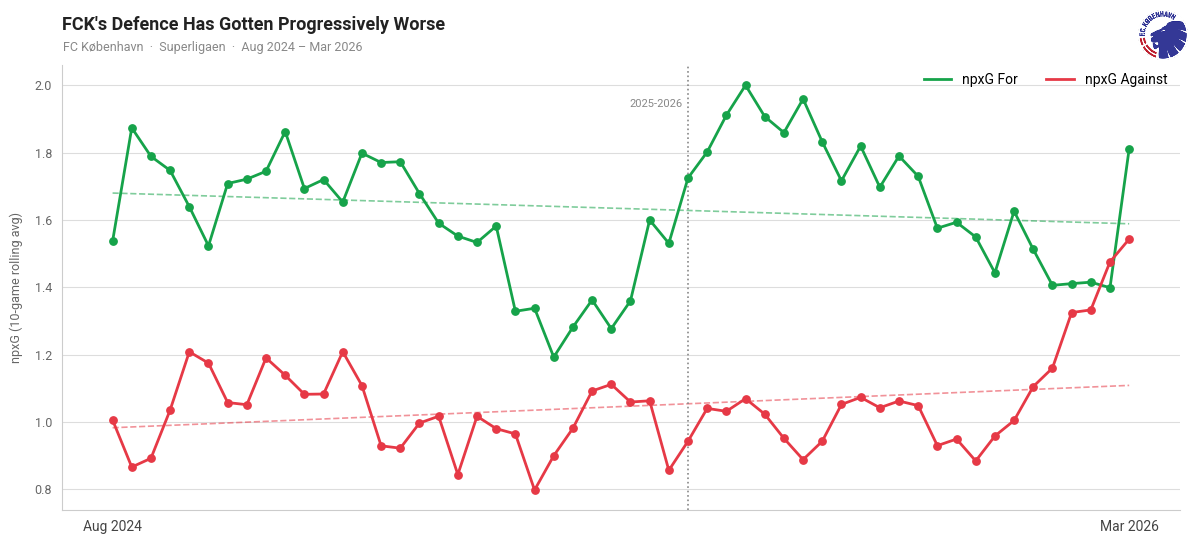

In [6]:
import sys
sys.path.insert(0, '/Users/admin/dev/algobetting')
from viz.npxg_trend_chart import plot_xg_trend

plot_df = xg[xg['team_name'] == 'FC København'].dropna(
    subset=['xg_for_roll10', 'xg_against_roll10']
).merge(matches[['match_id', 'season']].drop_duplicates(), on='match_id', how='left')

title = "FCK's Defence Has Gotten Progressively Worse"  # ← edit this

plot_xg_trend(
    plot_df=plot_df,
    title=title,
    team="FC København",
    league="Superligaen",
    save_path="fck_xg_rolling.png",
)

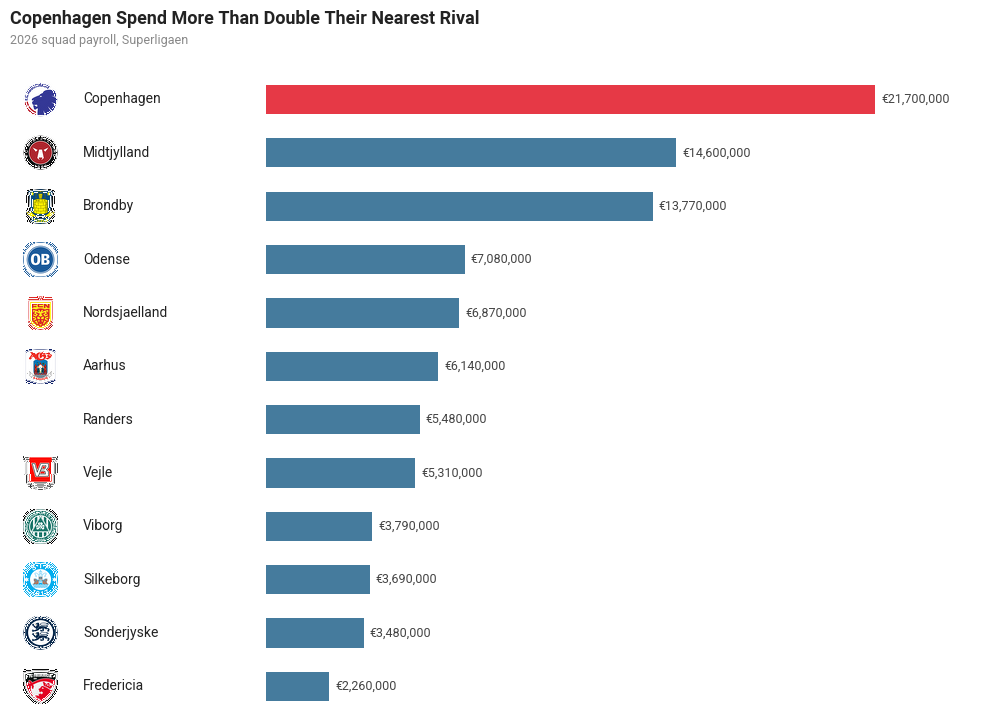

--- COPY EVERYTHING BELOW THIS LINE ---
Logo,Team,2026 Payroll
![](https://r2.thesportsdb.com/images/media/team/badge/styqtr1473535513.png),Copenhagen,21700000
![](https://r2.thesportsdb.com/images/media/team/badge/s5bpcr1755712262.png),Midtjylland,14600000
![](https://r2.thesportsdb.com/images/media/team/badge/ywswyw1473535498.png),Brondby,13770000
![](https://r2.thesportsdb.com/images/media/team/badge/syyxwq1473535545.png),Odense,7080000
![](https://r2.thesportsdb.com/images/media/team/badge/p2hof41579460164.png),Nordsjaelland,6870000
![](https://r2.thesportsdb.com/images/media/team/badge/vxuuts1473535487.png),Aarhus,6140000
![](https://upload.wikimedia.org/wikipedia/en/thumb/b/b7/Randers_FC_logo.svg/250px-Randers_FC_logo.svg.png),Randers,5480000
![](https://r2.thesportsdb.com/images/media/team/badge/fhlqev1532855346.png),Vejle,5310000
![](https://r2.thesportsdb.com/images/media/team/badge/uvrpsp1447539333.png),Viborg,3790000
![](https://r2.thesportsdb.com/images/media/team/badge/tpx

In [7]:
import sys
sys.path.insert(0, '/Users/admin/dev/algobetting')
from viz.bar_chart import plot_bar_chart, datawrapper_csv

payroll = {
    "Copenhagen":    21_700_000,
    "Midtjylland":   14_600_000,
    "Brondby":       13_770_000,
    "Odense":         7_080_000,
    "Nordsjaelland":  6_870_000,
    "Aarhus":         6_140_000,
    "Randers":        5_480_000,
    "Vejle":          5_310_000,
    "Viborg":         3_790_000,
    "Silkeborg":      3_690_000,
    "Sonderjyske":    3_480_000,
    "Fredericia":     2_260_000,
}

title    = "Copenhagen Spend More Than Double Their Nearest Rival"  # ← edit
subtitle = "2026 squad payroll, Superligaen"

plot_bar_chart(
    data=payroll,
    title=title,
    subtitle=subtitle,
    value_format="€{:,.0f}",
    highlight_team="Copenhagen",
    save_path="superligaen_payroll.png",
)

# Datawrapper CSV export
datawrapper_csv(payroll, value_label="2026 Payroll")

In [8]:
# =============================================================================
# FCK Season Comparison — diagnostic breakdown
# =============================================================================
FCK_ID = 8391

conn = sqlite3.connect(DB_PATH)

# npxG + shot counts for FCK
npshots_fck = pd.read_sql("""
    SELECT match_id, season,
           SUM(expectedGoals) AS npxg_for,
           COUNT(*)           AS np_shots_for
    FROM np_shots
    WHERE league_id = 'Superligaen'
      AND teamId = 8391
    GROUP BY match_id, season
""", conn)

# Opponent npxG/shots in same matches
npshots_opp = pd.read_sql("""
    SELECT match_id,
           SUM(expectedGoals) AS npxg_against,
           COUNT(*)           AS np_shots_against
    FROM np_shots
    WHERE league_id = 'Superligaen'
      AND teamId != 8391
      AND match_id IN (
            SELECT DISTINCT match_id FROM np_shots
            WHERE teamId = 8391 AND league_id = 'Superligaen'
          )
    GROUP BY match_id
""", conn)

# Non-penalty goals (actual scoreline)
goals = pd.read_sql("""
    SELECT match_id,
           CASE WHEN home_team = 8391 THEN home_goals ELSE away_goals END AS goals_for,
           CASE WHEN home_team = 8391 THEN away_goals ELSE home_goals END AS goals_against
    FROM np_matches
    WHERE league_id = 'Superligaen'
      AND (home_team = 8391 OR away_team = 8391)
""", conn)

# PSxG = expected_goals_on_target + total shots from match_stats
ms = pd.read_sql("""
    SELECT match_id,
           CASE WHEN home_team = 8391
                THEN home_expected_goals_on_target
                ELSE away_expected_goals_on_target END AS psxg_for,
           CASE WHEN home_team = 8391
                THEN away_expected_goals_on_target
                ELSE home_expected_goals_on_target END AS psxg_against,
           CASE WHEN home_team = 8391
                THEN home_total_shots ELSE away_total_shots END AS shots_for,
           CASE WHEN home_team = 8391
                THEN away_total_shots ELSE home_total_shots END AS shots_against
    FROM match_stats
    WHERE league_id = 'Superligaen'
      AND (home_team = 8391 OR away_team = 8391)
""", conn)

# Penalties awarded for and against
pens = pd.read_sql("""
    SELECT match_id,
           CASE WHEN home_team = 8391 THEN home_pens ELSE away_pens END AS pens_for,
           CASE WHEN home_team = 8391 THEN away_pens ELSE home_pens END AS pens_against
    FROM penalties
    WHERE league_id = 'Superligaen'
      AND (home_team = 8391 OR away_team = 8391)
""", conn)

conn.close()

# Coerce text columns
for col in ['psxg_for', 'psxg_against', 'shots_for', 'shots_against']:
    ms[col] = pd.to_numeric(ms[col], errors='coerce')

# ── Merge ─────────────────────────────────────────────────────────────────────
df = (npshots_fck
      .merge(npshots_opp, on='match_id', how='left')
      .merge(goals,       on='match_id', how='left')
      .merge(ms,          on='match_id', how='left')
      .merge(pens,        on='match_id', how='left'))

# ── Derived metrics ───────────────────────────────────────────────────────────
df['npxgd']                = df['npxg_for']      - df['npxg_against']
df['goals_minus_npxg']     = df['goals_for']     - df['npxg_for']
df['ga_minus_npxga']       = df['goals_against'] - df['npxg_against']
df['npxg_per_shot_for']    = df['npxg_for']      / df['np_shots_for']
df['npxg_per_shot_ag']     = df['npxg_against']  / df['np_shots_against']
df['psxg_diff_for']        = df['psxg_for']      - df['npxg_for']
df['psxg_diff_ag']         = df['psxg_against']  - df['npxg_against']
df['goals_minus_psxg_for'] = df['goals_for']     - df['psxg_for']
df['goals_minus_psxg_ag']  = df['goals_against'] - df['psxg_against']

# ── Season averages ───────────────────────────────────────────────────────────
comp = df.groupby('season').agg(
    Games               = ('match_id',             'count'),
    npxG_for            = ('npxg_for',             'mean'),
    npxGA               = ('npxg_against',          'mean'),
    npxGD               = ('npxgd',                'mean'),
    Goals_for           = ('goals_for',            'mean'),
    Goals_against       = ('goals_against',        'mean'),
    Goals_minus_npxG    = ('goals_minus_npxg',     'mean'),
    GA_minus_npxGA      = ('ga_minus_npxga',       'mean'),
    PSxG_for            = ('psxg_for',             'mean'),
    PSxG_against        = ('psxg_against',         'mean'),
    PSxG_diff_for       = ('psxg_diff_for',        'mean'),
    PSxG_diff_ag        = ('psxg_diff_ag',         'mean'),
    Goals_minus_PSxG    = ('goals_minus_psxg_for', 'mean'),
    GA_minus_PSxG       = ('goals_minus_psxg_ag',  'mean'),
    npxG_per_shot_for   = ('npxg_per_shot_for',    'mean'),
    npxG_per_shot_ag    = ('npxg_per_shot_ag',     'mean'),
    Shots_for_pg        = ('shots_for',            'mean'),
    Shots_against_pg    = ('shots_against',        'mean'),
    Pens_for            = ('pens_for',             'sum'),
    Pens_against        = ('pens_against',         'sum'),
).round(3)

comp.T

season,2024-2025,2025-2026
Games,32.000,24.000
npxG_for,1.622,1.766
npxGA,0.999,1.239
npxGD,0.623,0.526
Goals_for,1.656,1.292
Goals_against,0.938,1.333
Goals_minus_npxG,0.034,-0.474
GA_minus_npxGA,-0.062,0.094
PSxG_for,1.966,1.773
PSxG_against,0.996,1.472


In [9]:
# =============================================================================
# Datawrapper table exports — key metrics, attack & defence
# =============================================================================
import io, csv

s24, s25 = '2024-2025', '2025-2026'
c = comp

def dw_table(metrics, label):
    out = io.StringIO()
    w = csv.writer(out)
    w.writerow(['Metric', '2024-25', '2025-26'])
    for display_label, col in metrics:
        v24 = round(c.loc[s24, col], 2)
        v25 = round(c.loc[s25, col], 2)
        w.writerow([display_label, v24, v25])
    print(f"--- {label} — COPY EVERYTHING BELOW ---")
    print(out.getvalue())

dw_table([
    ('npxG per game',         'npxG_for'),
    ('Shots per game',        'Shots_for_pg'),
    ('npxG per shot',         'npxG_per_shot_for'),
    ('Goals per game',        'Goals_for'),
    ('Goals vs npxG',         'Goals_minus_npxG'),
    ('Shot placement (PSxG-npxG)', 'PSxG_diff_for'),
], 'ATTACK')

dw_table([
    ('npxGA per game',              'npxGA'),
    ('Shots against per game',      'Shots_against_pg'),
    ('Opp. npxG per shot',          'npxG_per_shot_ag'),
    ('Goals conceded per game',     'Goals_against'),
    ('GA vs npxGA',                 'GA_minus_npxGA'),
    ('Opp. shot placement (PSxG-npxG)', 'PSxG_diff_ag'),
    ('Penalties conceded',          'Pens_against'),
], 'DEFENCE')

--- ATTACK — COPY EVERYTHING BELOW ---
Metric,2024-25,2025-26
npxG per game,1.62,1.77
Shots per game,15.75,16.71
npxG per shot,0.11,0.11
Goals per game,1.66,1.29
Goals vs npxG,0.03,-0.47
Shot placement (PSxG-npxG),0.34,0.01

--- DEFENCE — COPY EVERYTHING BELOW ---
Metric,2024-25,2025-26
npxGA per game,1.0,1.24
Shots against per game,9.84,9.88
Opp. npxG per shot,0.11,0.13
Goals conceded per game,0.94,1.33
GA vs npxGA,-0.06,0.09
Opp. shot placement (PSxG-npxG),-0.0,0.23
Penalties conceded,3,6



In [10]:
# =============================================================================
# Datawrapper table — summary differentials
# =============================================================================
import io, csv

s24, s25 = '2024-2025', '2025-2026'
c = comp

# Compute GD from goals for/against
gd_24 = round(c.loc[s24, 'Goals_for']    - c.loc[s24, 'Goals_against'], 2)
gd_25 = round(c.loc[s25, 'Goals_for']    - c.loc[s25, 'Goals_against'], 2)

out = io.StringIO()
w = csv.writer(out)
w.writerow(['Metric', '2024-25', '2025-26'])
w.writerow(['npxGD per game',    round(c.loc[s24, 'npxGD'], 2),           round(c.loc[s25, 'npxGD'], 2)])
w.writerow(['GD per game',       gd_24,                                    gd_25])
w.writerow(['Goals vs npxG',     round(c.loc[s24, 'Goals_minus_npxG'], 2), round(c.loc[s25, 'Goals_minus_npxG'], 2)])
w.writerow(['GA vs npxGA',       round(c.loc[s24, 'GA_minus_npxGA'], 2),   round(c.loc[s25, 'GA_minus_npxGA'], 2)])
w.writerow(['Shot placement for (PSxG-npxG)', round(c.loc[s24, 'PSxG_diff_for'], 2), round(c.loc[s25, 'PSxG_diff_for'], 2)])
w.writerow(['Shot placement ag (PSxG-npxG)',  round(c.loc[s24, 'PSxG_diff_ag'], 2),  round(c.loc[s25, 'PSxG_diff_ag'], 2)])

print("--- SUMMARY — COPY EVERYTHING BELOW ---")
print(out.getvalue())

--- SUMMARY — COPY EVERYTHING BELOW ---
Metric,2024-25,2025-26
npxGD per game,0.62,0.53
GD per game,0.72,-0.04
Goals vs npxG,0.03,-0.47
GA vs npxGA,-0.06,0.09
Shot placement for (PSxG-npxG),0.34,0.01
Shot placement ag (PSxG-npxG),-0.0,0.23



In [11]:
# # =============================================================================
# # Datawrapper table — FCK player finishing 2025-26 (min 5 shots)
# # =============================================================================
# import io, csv

# player_shots['is_goal'] = (player_shots['eventType'] == 'Goal').astype(int)

# p25 = (player_shots[player_shots['season'] == '2025-2026']
#     .groupby('playerName')
#     .agg(Shots=('expectedGoals','count'), npxG=('expectedGoals','sum'), Goals=('is_goal','sum'))
#     .reset_index()
# )
# p25['Goals_vs_npxG'] = (p25['Goals'] - p25['npxG']).round(2)
# p25['npxG']          = p25['npxG'].round(2)
# p25 = p25[p25['Shots'] >= 5].sort_values('npxG', ascending=False)

# out = io.StringIO()
# w = csv.writer(out)
# w.writerow(['Player', 'Shots', 'npxG', 'Goals', 'Goals vs npxG'])
# for _, row in p25.iterrows():
#     w.writerow([
#         row['playerName'],
#         int(row['Shots']),
#         row['npxG'],
#         int(row['Goals']),
#         row['Goals_vs_npxG'],
#     ])

# print("--- PLAYER FINISHING — COPY EVERYTHING BELOW ---")
# print(out.getvalue())

In [12]:
# =============================================================================
# League-wide season averages — used to scale radar axes
# =============================================================================
conn = sqlite3.connect(DB_PATH)

# npxG + shot counts per team per match
lshots = pd.read_sql("""
    SELECT match_id, season, teamId AS team_id,
           SUM(expectedGoals) AS npxg_for,
           COUNT(*)           AS np_shots_for
    FROM np_shots
    WHERE league_id = 'Superligaen'
    GROUP BY match_id, season, teamId
""", conn)

# Opponent stats: self-join on match_id where team != opponent
opp = (lshots[['match_id','team_id','npxg_for','np_shots_for']]
       .rename(columns={'team_id':'opp_id','npxg_for':'npxg_against',
                          'np_shots_for':'np_shots_against'}))
lshots = (lshots
    .merge(opp, on='match_id', how='left')
    .query('team_id != opp_id')
    .drop(columns='opp_id'))

# Goals: unpivot np_matches home/away -> team rows
graw = pd.read_sql("""
    SELECT match_id, home_team, away_team, home_goals, away_goals
    FROM np_matches WHERE league_id = 'Superligaen'
""", conn)
goals_long = pd.concat([
    graw[['match_id','home_team','home_goals','away_goals']].rename(
        columns={'home_team':'team_id','home_goals':'goals_for','away_goals':'goals_against'}),
    graw[['match_id','away_team','away_goals','home_goals']].rename(
        columns={'away_team':'team_id','away_goals':'goals_for','home_goals':'goals_against'}),
])

# Match stats: shots
msraw = pd.read_sql("""
    SELECT match_id, home_team, away_team, home_total_shots, away_total_shots
    FROM match_stats WHERE league_id = 'Superligaen'
""", conn)
for c in ['home_total_shots','away_total_shots']:
    msraw[c] = pd.to_numeric(msraw[c], errors='coerce')
ms_long = pd.concat([
    msraw[['match_id','home_team','home_total_shots','away_total_shots']].rename(
        columns={'home_team':'team_id','home_total_shots':'shots_for','away_total_shots':'shots_against'}),
    msraw[['match_id','away_team','away_total_shots','home_total_shots']].rename(
        columns={'away_team':'team_id','away_total_shots':'shots_for','home_total_shots':'shots_against'}),
])

# Penalties
praw = pd.read_sql("""
    SELECT match_id, home_team, away_team, home_pens, away_pens
    FROM penalties WHERE league_id = 'Superligaen'
""", conn)
conn.close()
pens_long = pd.concat([
    praw[['match_id','home_team','home_pens','away_pens']].rename(
        columns={'home_team':'team_id','home_pens':'pens_for','away_pens':'pens_against'}),
    praw[['match_id','away_team','away_pens','home_pens']].rename(
        columns={'away_team':'team_id','away_pens':'pens_for','home_pens':'pens_against'}),
])

# Merge and derive
ldf = (lshots
    .merge(goals_long, on=['match_id','team_id'], how='left')
    .merge(ms_long,    on=['match_id','team_id'], how='left')
    .merge(pens_long,  on=['match_id','team_id'], how='left'))

ldf['npxg_per_shot_for'] = ldf['npxg_for']     / ldf['np_shots_for']
ldf['npxg_per_shot_ag']  = ldf['npxg_against'] / ldf['np_shots_against']
ldf['goals_minus_npxg']  = ldf['goals_for']    - ldf['npxg_for']
ldf['ga_minus_npxga']    = ldf['goals_against']- ldf['npxg_against']

league_stats = ldf.groupby(['team_id','season']).agg(
    npxG_for          = ('npxg_for',          'mean'),
    npxGA             = ('npxg_against',       'mean'),
    Goals_for         = ('goals_for',          'mean'),
    Goals_against     = ('goals_against',      'mean'),
    Goals_minus_npxG  = ('goals_minus_npxg',   'mean'),
    GA_minus_npxGA    = ('ga_minus_npxga',     'mean'),
    npxG_per_shot_for = ('npxg_per_shot_for',  'mean'),
    npxG_per_shot_ag  = ('npxg_per_shot_ag',   'mean'),
    Shots_for_pg      = ('shots_for',          'mean'),
    Shots_against_pg  = ('shots_against',      'mean'),
    Pens_against      = ('pens_against',       'sum'),
).round(3)

league_stats


npxG_for  npxGA  Goals_for  Goals_against  \
team_id season                                                 
8071    2024-2025     1.544  1.129      1.562          1.312   
        2025-2026     1.701  1.093      1.750          0.917   
8113    2024-2025     1.578  1.418      1.781          1.188   
        2025-2026     1.842  1.147      2.375          0.917   
8231    2024-2025     1.125  1.615      1.125          1.875   
        2025-2026     1.028  1.552      1.083          1.875   
8391    2024-2025     1.622  0.999      1.656          0.938   
        2025-2026     1.766  1.239      1.292          1.333   
8410    2024-2025     1.262  1.212      1.576          1.515   
        2025-2026     1.304  1.363      0.917          1.208   
8414    2025-2026     1.354  1.515      1.417          1.917   
8415    2024-2025     1.311  1.335      1.636          1.121   
        2025-2026     1.102  1.656      1.083          1.750   
8454    2025-2026     1.165  2.008      1.292          1.958   
8470    2024-2025     1.209  1.557      1.000          1.938   
8487    2024-2025     1.174  1.830      1.406          1.906   
        2025-2026     1.370  1.453      1.292          1.208   
8595    2024-2025     1.552  1.143      1.688          1.281   
        2025-2026     1.424  1.190      1.208          0.792   
9907    2024-2025     0.935  1.478      0.781          1.219   
9939    2024-2025     1.514  1.391      1.656          1.500   
        2025-2026     1.453  1.305      1.500          1.333   
10202   2024-2025     1.528  1.246      1.594          1.688   
        2025-2026     1.438  1.425      1.583          1.583   

                   Goals_minus_npxG  GA_minus_npxGA  npxG_per_shot_for  \
team_id season                                                           
8071    2024-2025             0.018           0.183              0.113   
        2025-2026             0.049          -0.177              0.112   
8113    2024-2025             0.203          -0.230              0.112   
        2025-2026             0.533          -0.230              0.127   
8231    2024-2025             0.000           0.260              0.100   
        2025-2026             0.055           0.323              0.090   
8391    2024-2025             0.034          -0.062              0.112   
        2025-2026            -0.474           0.094              0.106   
8410    2024-2025             0.314           0.303              0.113   
        2025-2026            -0.388          -0.155              0.110   
8414    2025-2026             0.062           0.402              0.119   
8415    2024-2025             0.326          -0.214              0.115   
        2025-2026            -0.019           0.094              0.103   
8454    2025-2026             0.126          -0.050              0.112   
8470    2024-2025            -0.209           0.381              0.104   
8487    2024-2025             0.233           0.077              0.115   
        2025-2026            -0.078          -0.245              0.119   
8595    2024-2025             0.135           0.139              0.103   
        2025-2026            -0.216          -0.398              0.107   
9907    2024-2025            -0.153          -0.260              0.090   
9939    2024-2025             0.142           0.109              0.112   
        2025-2026             0.047           0.028              0.119   
10202   2024-2025             0.066           0.441              0.109   
        2025-2026             0.146           0.158              0.109   

                   npxG_per_shot_ag  Shots_for_pg  Shots_against_pg  \
team_id season                                                        
8071    2024-2025             0.111        13.562            10.188   
        2025-2026             0.103        16.000            10.625   
8113    2024-2025             0.111        14.750            13.500   
        2025-2026             0.098        14.417            12.125   
823

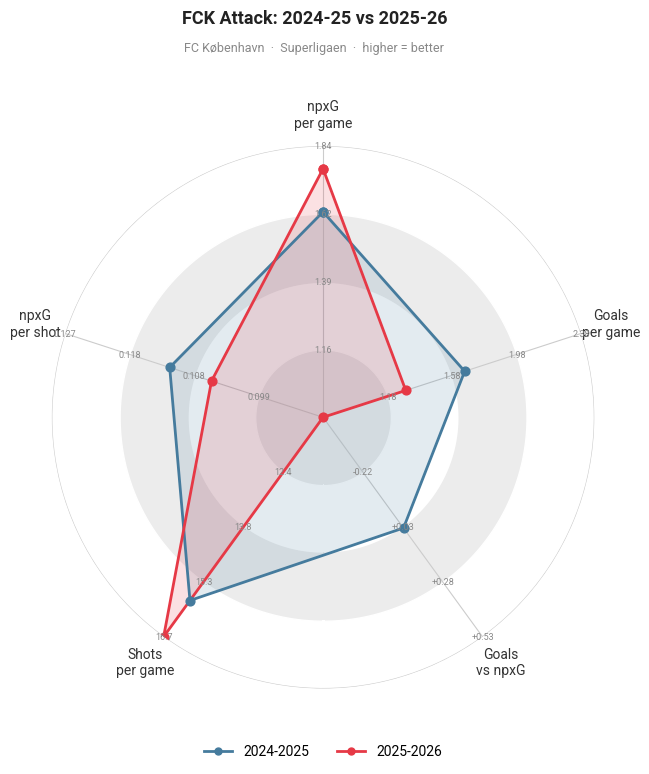

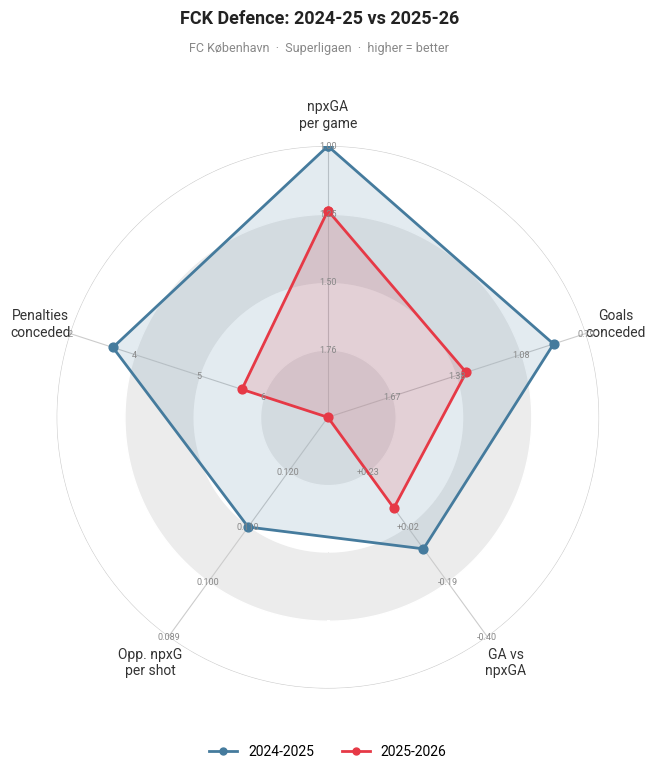

In [13]:
import sys
sys.path.insert(0, '/Users/admin/dev/algobetting')
from viz.radar_chart import make_radar

s24, s25 = '2024-2025', '2025-2026'

ATTACK = [
    ('npxG\nper game',      'npxG_for',          False, '{:.2f}'),
    ('Goals\nper game',     'Goals_for',          False, '{:.2f}'),
    ('Goals\nvs npxG',      'Goals_minus_npxG',   False, '{:+.2f}'),
    ('Shots\nper game',     'Shots_for_pg',        False, '{:.1f}'),
    ('npxG\nper shot',      'npxG_per_shot_for',   False, '{:.3f}'),
]

DEFENCE = [
    ('npxGA\nper game',     'npxGA',               True,  '{:.2f}'),
    ('Goals\nconceded',     'Goals_against',        True,  '{:.2f}'),
    ('GA vs\nnpxGA',        'GA_minus_npxGA',       True,  '{:+.2f}'),
    ('Opp. npxG\nper shot', 'npxG_per_shot_ag',     True,  '{:.3f}'),
    ('Penalties\nconceded', 'Pens_against',         True,  '{:.0f}'),
]

make_radar(
    comp=comp,
    metrics=ATTACK,
    season_a=s24,
    season_b=s25,
    title='FCK Attack: 2024-25 vs 2025-26',
    subtitle='FC København  ·  Superligaen  ·  higher = better',
    league_df=league_stats,
    save_path='fck_radar_attack.png',
)

make_radar(
    comp=comp,
    metrics=DEFENCE,
    season_a=s24,
    season_b=s25,
    title='FCK Defence: 2024-25 vs 2025-26',
    subtitle='FC København  ·  Superligaen  ·  higher = better',
    league_df=league_stats,
    save_path='fck_radar_defence.png',
)


In [14]:
# =============================================================================
# xPts league table — Superligaen 2025-2026 (all shots incl. penalties)
# =============================================================================
from scipy.stats import poisson

conn = sqlite3.connect(DB_PATH)

xg_all = pd.read_sql("""
    SELECT match_id, teamId, SUM(expectedGoals) AS xg
    FROM shots
    WHERE league_id = 'Superligaen' AND season = '2025-2026'
    GROUP BY match_id, teamId
""", conn)

results = pd.read_sql("""
    SELECT match_id, home_team, away_team, home_goals, away_goals
    FROM matches
    WHERE league_id = 'Superligaen' AND season = '2025-2026'
""", conn)

names = pd.read_sql("SELECT team_id, team_name FROM team_id_mapping", conn)
conn.close()

# Build per-match, per-team rows
home = results[['match_id','home_team','away_team','home_goals','away_goals']].copy()
home = home.merge(
    xg_all.rename(columns={'teamId':'home_team','xg':'xg_for'}), on=['match_id','home_team'], how='left'
).merge(
    xg_all.rename(columns={'teamId':'away_team','xg':'xg_ag'}),  on=['match_id','away_team'], how='left'
)
home['team']       = home['home_team']
home['goals_for']  = home['home_goals']
home['goals_ag']   = home['away_goals']

away = results[['match_id','home_team','away_team','home_goals','away_goals']].copy()
away = away.merge(
    xg_all.rename(columns={'teamId':'away_team','xg':'xg_for'}), on=['match_id','away_team'], how='left'
).merge(
    xg_all.rename(columns={'teamId':'home_team','xg':'xg_ag'}),  on=['match_id','home_team'], how='left'
)
away['team']       = away['away_team']
away['goals_for']  = away['away_goals']
away['goals_ag']   = away['home_goals']

matches_long = pd.concat([
    home[['match_id','team','xg_for','xg_ag','goals_for','goals_ag']],
    away[['match_id','team','xg_for','xg_ag','goals_for','goals_ag']],
])

matches_long['actual_pts'] = np.where(
    matches_long['goals_for'] > matches_long['goals_ag'], 3,
    np.where(matches_long['goals_for'] == matches_long['goals_ag'], 1, 0)
)

MAX_GOALS = 10

def xpts_poisson(xg_for, xg_ag):
    win = draw = 0.0
    for i in range(MAX_GOALS + 1):
        for j in range(MAX_GOALS + 1):
            p = poisson.pmf(i, xg_for) * poisson.pmf(j, xg_ag)
            if i > j:    win  += p
            elif i == j: draw += p
    return 3 * win + draw

matches_long = matches_long.dropna(subset=['xg_for','xg_ag'])
matches_long['xpts'] = matches_long.apply(
    lambda r: xpts_poisson(r['xg_for'], r['xg_ag']), axis=1
)

table = matches_long.groupby('team').agg(
    Games      = ('match_id',   'count'),
    Goals_for  = ('goals_for',  'sum'),
    Goals_ag   = ('goals_ag',   'sum'),
    Actual_Pts = ('actual_pts', 'sum'),
    xPts       = ('xpts',       'sum'),
).round(1)

table['GD']          = table['Goals_for'] - table['Goals_ag']
table['Pts_vs_xPts'] = (table['Actual_Pts'] - table['xPts']).round(1)
table = table.merge(names, left_index=True, right_on='team_id').set_index('team_name')
table = table[['Games','Goals_for','Goals_ag','GD','Actual_Pts','xPts','Pts_vs_xPts']].sort_values('Actual_Pts', ascending=False)

table

,Games,Goals_for,Goals_ag,GD,Actual_Pts,xPts,Pts_vs_xPts
team_name,,,,,,,
AGF,24,47,24,23,52,44.6,7.4
FC Midtjylland,24,59,25,34,47,41.5,5.5
Sønderjyske,24,35,31,4,37,33.7,3.3
Viborg,24,39,36,3,37,35.5,1.5
Nordsjælland,24,40,39,1,37,33.5,3.5
Brøndby IF,24,31,23,8,35,34.8,0.2
OB,24,39,48,-9,31,33.1,-2.1
FC København,24,37,38,-1,29,39.4,-10.4
Randers FC,24,25,30,-5,29,32.9,-3.9


In [15]:
# =============================================================================
# Datawrapper export — xPts league table
# =============================================================================
import sys, io, csv
sys.path.insert(0, '/Users/admin/dev/algobetting')
from viz.logos import TEAM_LOGOS

# Aggregate xG totals with team names attached
xg_totals = (matches_long
    .merge(names, left_on='team', right_on='team_id', how='left')
    .groupby('team_name')
    .agg(xG_for=('xg_for','sum'), xG_ag=('xg_ag','sum'))
    .round(1)
)

dw = table.join(xg_totals)

# Diff columns
dw['Goals_vs_xG'] = (dw['Goals_for'] - dw['xG_for']).round(1)
dw['GA_vs_xGA']   = (dw['Goals_ag']  - dw['xG_ag']).round(1)
dw['Pts_vs_xPts'] = (dw['Actual_Pts'] - dw['xPts']).round(1)

def fmt_diff(val):
    return f"+{val}" if val > 0 else str(val)

out = io.StringIO()
w = csv.writer(out)
w.writerow(['Logo', 'Team', 'xG', 'Goals vs xG', 'xGA', 'GA vs xGA', 'xPts', 'Pts vs xPts'])

for team_name, row in dw.iterrows():
    logo_url = TEAM_LOGOS.get(team_name, '')
    logo_md  = f"![]({logo_url})" if logo_url else ''
    w.writerow([
        logo_md,
        team_name,
        row['xG_for'],
        fmt_diff(row['Goals_vs_xG']),
        row['xG_ag'],
        fmt_diff(row['GA_vs_xGA']),
        row['xPts'],
        fmt_diff(row['Pts_vs_xPts']),
    ])

print("--- COPY EVERYTHING BELOW THIS LINE ---")
print(out.getvalue())

--- COPY EVERYTHING BELOW THIS LINE ---
Logo,Team,xG,Goals vs xG,xGA,GA vs xGA,xPts,Pts vs xPts
![](https://r2.thesportsdb.com/images/media/team/badge/vxuuts1473535487.png),AGF,47.1,-0.1,27.8,-3.8,44.6,+7.4
![](https://r2.thesportsdb.com/images/media/team/badge/s5bpcr1755712262.png),FC Midtjylland,45.8,+13.2,30.7,-5.7,41.5,+5.5
![](https://r2.thesportsdb.com/images/media/team/badge/04mzis1677238771.png),Sønderjyske,36.0,-1.0,36.5,-5.5,33.7,+3.3
![](https://r2.thesportsdb.com/images/media/team/badge/uvrpsp1447539333.png),Viborg,38.0,+1.0,34.5,+1.5,35.5,+1.5
![](https://r2.thesportsdb.com/images/media/team/badge/p2hof41579460164.png),Nordsjælland,36.1,+3.9,36.6,+2.4,33.5,+3.5
![](https://r2.thesportsdb.com/images/media/team/badge/ywswyw1473535498.png),Brøndby IF,35.8,-4.8,32.5,-9.5,34.8,+0.2
![](https://r2.thesportsdb.com/images/media/team/badge/syyxwq1473535545.png),OB,36.4,+2.6,37.9,+10.1,33.1,-2.1
![](https://r2.thesportsdb.com/images/media/team/badge/styqtr1473535513.png),FC Københav

In [16]:
# =============================================================================
# 1. Home vs Away split
# =============================================================================
conn = sqlite3.connect(DB_PATH)
venue = pd.read_sql("""
    SELECT match_id,
           CASE WHEN home_team = 8391 THEN 'Home' ELSE 'Away' END AS venue
    FROM np_matches
    WHERE league_id = 'Superligaen'
      AND (home_team = 8391 OR away_team = 8391)
""", conn)
conn.close()

df_venue = df.merge(venue, on='match_id', how='left')

home_away = df_venue.groupby(['season', 'venue']).agg(
    Games             = ('match_id',          'count'),
    npxG_for          = ('npxg_for',          'mean'),
    npxGA             = ('npxg_against',       'mean'),
    npxGD             = ('npxgd',             'mean'),
    Goals_for         = ('goals_for',         'mean'),
    Goals_against     = ('goals_against',     'mean'),
    Goals_minus_npxG  = ('goals_minus_npxg',  'mean'),
    GA_minus_npxGA    = ('ga_minus_npxga',    'mean'),
    Pens_for          = ('pens_for',          'sum'),
    Pens_against      = ('pens_against',      'sum'),
).round(3)

home_away.T

season           2024-2025         2025-2026        
venue                 Away    Home      Away    Home
Games               16.000  16.000    12.000  12.000
npxG_for             1.498   1.746     1.617   1.914
npxGA                1.227   0.771     1.245   1.233
npxGD                0.271   0.975     0.373   0.680
Goals_for            1.688   1.625     1.667   0.917
Goals_against        1.062   0.812     1.417   1.250
Goals_minus_npxG     0.190  -0.121     0.049  -0.997
GA_minus_npxGA      -0.165   0.041     0.172   0.017
Pens_for             2.000   6.000     1.000   5.000
Pens_against         1.000   2.000     3.000   3.000

In [17]:
# =============================================================================
# 2. Big chances — created vs missed
# =============================================================================
conn = sqlite3.connect(DB_PATH)
big_chances = pd.read_sql("""
    SELECT m.match_id, m.season,
           CASE WHEN ms.home_team = 8391
                THEN ms.home_big_chance ELSE ms.away_big_chance END  AS big_chances_for,
           CASE WHEN ms.home_team = 8391
                THEN ms.away_big_chance ELSE ms.home_big_chance END  AS big_chances_against,
           CASE WHEN ms.home_team = 8391
                THEN ms.home_big_chance_missed_title
                ELSE ms.away_big_chance_missed_title END              AS big_chances_missed
    FROM match_stats ms
    JOIN np_matches m ON ms.match_id = m.match_id
    WHERE ms.league_id = 'Superligaen'
      AND (ms.home_team = 8391 OR ms.away_team = 8391)
""", conn)
conn.close()

for col in ['big_chances_for', 'big_chances_against', 'big_chances_missed']:
    big_chances[col] = pd.to_numeric(big_chances[col], errors='coerce')

# Conversion rate = (big chances - missed) / big chances
bc = big_chances.groupby('season').agg(
    Games              = ('match_id',           'count'),
    BigChances_for     = ('big_chances_for',     'sum'),
    BigChances_against = ('big_chances_against', 'sum'),
    BigChances_missed  = ('big_chances_missed',  'sum'),
).assign(
    BigChance_conversion_pct = lambda x: ((x['BigChances_for'] - x['BigChances_missed']) / x['BigChances_for'] * 100).round(1),
    BigChances_for_pg        = lambda x: (x['BigChances_for']     / x['Games']).round(2),
    BigChances_against_pg    = lambda x: (x['BigChances_against'] / x['Games']).round(2),
)

bc.T

season,2024-2025,2025-2026
Games,32.00,24.00
BigChances_for,89.00,67.00
BigChances_against,57.00,54.00
BigChances_missed,49.00,43.00
BigChance_conversion_pct,44.90,35.80
BigChances_for_pg,2.78,2.79
BigChances_against_pg,1.78,2.25


In [18]:
# =============================================================================
# 3. Red cards — minutes played with 10 men
# =============================================================================
conn = sqlite3.connect(DB_PATH)
red_cards = pd.read_sql("""
    SELECT rc.match_id, rc.season, rc.time,
           CASE WHEN rc.team_id = 8391 THEN 'FCK' ELSE 'Opponent' END AS team
    FROM red_cards rc
    WHERE rc.league_id = 'Superligaen'
      AND rc.match_id IN (
            SELECT DISTINCT match_id FROM np_shots
            WHERE teamId = 8391 AND league_id = 'Superligaen'
          )
""", conn)
conn.close()

red_cards['time'] = pd.to_numeric(red_cards['time'], errors='coerce')
red_cards['mins_reduced'] = (90 - red_cards['time']).clip(lower=0)

rc_summary = red_cards.groupby(['season', 'team']).agg(
    Red_cards       = ('match_id', 'count'),
    Avg_time        = ('time',          'mean'),
    Total_mins_10men= ('mins_reduced',  'sum'),
).round(1)

print("Red cards by season and team:")
print(rc_summary.to_string())
print()
print("Matches with a FCK red card:")
print(red_cards[red_cards['team'] == 'FCK'][['match_id','season','time']].to_string(index=False))

Red cards by season and team:
                    Red_cards  Avg_time  Total_mins_10men
season    team                                           
2024-2025 FCK               2      66.5                47
          Opponent          3      69.0                63
2025-2026 FCK               2      80.0                20
          Opponent          2      67.5                45

Matches with a FCK red card:
 match_id    season  time
  4801993 2025-2026    90
  4802046 2025-2026    70
  4494908 2024-2025    43
  4757620 2024-2025    90


In [19]:
# =============================================================================
# 4. Goalkeeper / shots on target — saves%, SoT against
# =============================================================================
conn = sqlite3.connect(DB_PATH)
gk = pd.read_sql("""
    SELECT m.match_id, m.season,
           CASE WHEN ms.home_team = 8391
                THEN ms.home_ShotsOnTarget ELSE ms.away_ShotsOnTarget END AS sot_for,
           CASE WHEN ms.home_team = 8391
                THEN ms.away_ShotsOnTarget ELSE ms.home_ShotsOnTarget END AS sot_against,
           CASE WHEN ms.home_team = 8391
                THEN ms.home_keeper_saves  ELSE ms.away_keeper_saves  END AS saves_for,
           CASE WHEN ms.home_team = 8391
                THEN ms.away_keeper_saves  ELSE ms.home_keeper_saves  END AS saves_against
    FROM match_stats ms
    JOIN np_matches m ON ms.match_id = m.match_id
    WHERE ms.league_id = 'Superligaen'
      AND (ms.home_team = 8391 OR ms.away_team = 8391)
""", conn)
conn.close()

for col in ['sot_for','sot_against','saves_for','saves_against']:
    gk[col] = pd.to_numeric(gk[col], errors='coerce')

gk_summary = gk.groupby('season').agg(
    Games        = ('match_id',    'count'),
    SoT_for_pg   = ('sot_for',    'mean'),
    SoT_ag_pg    = ('sot_against', 'mean'),
    Saves_pg     = ('saves_for',  'mean'),   # FCK GK saves per game
).round(2)

# Save % = saves / SoT against  (across full season)
totals = gk.groupby('season')[['sot_against','saves_for']].sum()
gk_summary['GK_save_pct'] = (totals['saves_for'] / totals['sot_against'] * 100).round(1)

# Opponent save % (FCK shots on target vs opponent saves)
totals2 = gk.groupby('season')[['sot_for','saves_against']].sum()
gk_summary['Opp_save_pct'] = (totals2['saves_against'] / totals2['sot_for'] * 100).round(1)

gk_summary.T

season,2024-2025,2025-2026
Games,32.00,24.00
SoT_for_pg,5.66,5.21
SoT_ag_pg,3.19,4.33
Saves_pg,2.06,2.75
GK_save_pct,64.70,63.50
Opp_save_pct,66.30,68.80


In [20]:
# =============================================================================
# 5. Within-season trend — 2025-26 first half vs second half
# =============================================================================
fck_25 = df[df['season'] == '2025-2026'].copy()
fck_25 = fck_25.merge(
    matches[['match_id','match_date']].drop_duplicates(), on='match_id', how='left'
)
fck_25['match_date'] = pd.to_datetime(fck_25['match_date'])
fck_25 = fck_25.sort_values('match_date').reset_index(drop=True)

mid = len(fck_25) // 2
fck_25['half'] = ['First half' if i < mid else 'Second half' for i in range(len(fck_25))]
fck_25['half_label'] = fck_25['half'] + ' (' + fck_25['match_date'].dt.strftime('%b %Y') + ')'

# Use first/last date of each half for label
labels = fck_25.groupby('half')['match_date'].agg(['min','max'])
fck_25['half_label'] = fck_25['half'].map(
    {h: f"{h}\n({labels.loc[h,'min'].strftime('%b %Y')}–{labels.loc[h,'max'].strftime('%b %Y')})"
     for h in labels.index}
)

trend = fck_25.groupby('half_label').agg(
    Games            = ('match_id',          'count'),
    npxG_for         = ('npxg_for',          'mean'),
    npxGA            = ('npxg_against',       'mean'),
    npxGD            = ('npxgd',             'mean'),
    Goals_for        = ('goals_for',         'mean'),
    Goals_against    = ('goals_against',     'mean'),
    Goals_minus_npxG = ('goals_minus_npxg',  'mean'),
    GA_minus_npxGA   = ('ga_minus_npxga',    'mean'),
    PSxG_diff_for    = ('psxg_diff_for',     'mean'),
    PSxG_diff_ag     = ('psxg_diff_ag',      'mean'),
    npxG_per_shot_ag = ('npxg_per_shot_ag',  'mean'),
    Pens_against     = ('pens_against',      'sum'),
).round(3)

# Sort chronologically
trend = trend.loc[sorted(trend.index)]
trend.T

half_label,First half\n(Jul 2025–Oct 2025),Second half\n(Oct 2025–Mar 2026)
Games,12.000,12.000
npxG_for,1.834,1.697
npxGA,1.082,1.396
npxGD,0.752,0.301
Goals_for,1.917,0.667
Goals_against,1.250,1.417
Goals_minus_npxG,0.083,-1.030
GA_minus_npxGA,0.168,0.021
PSxG_diff_for,0.254,-0.240
PSxG_diff_ag,0.156,0.309


In [21]:
# =============================================================================
# 6. Player finishing — goals vs npxG by season
# =============================================================================
conn = sqlite3.connect(DB_PATH)
player_shots = pd.read_sql("""
    SELECT playerName, season, eventType,
           expectedGoals, expectedGoalsOnTarget
    FROM np_shots
    WHERE league_id = 'Superligaen'
      AND teamId = 8391
""", conn)
conn.close()

# Peek at eventType values so we know what 'goal' looks like
print("eventType values:", player_shots['eventType'].unique())
player_shots.head()

eventType values: <StringArray>
['Miss', 'Post', 'AttemptSaved', 'Goal']
Length: 4, dtype: str


,playerName,season,eventType,expectedGoals,expectedGoalsOnTarget
0,Viktor Claesson,2025-2026,Miss,0.358719,0.000000
1,Rodrigo Huescas,2025-2026,Miss,0.049828,0.000000
2,Viktor Claesson,2025-2026,Post,0.595250,0.000000
3,Jordan Larsson,2025-2026,AttemptSaved,0.085980,0.798158
4,Robert,2025-2026,Goal,0.610603,0.643018


In [22]:
# =============================================================================
# 6b. Player finishing — goals vs npxG by season (min 5 shots)
# =============================================================================
player_shots['is_goal'] = (player_shots['eventType'] == 'Goal').astype(int)

player = player_shots.groupby(['playerName', 'season']).agg(
    Shots   = ('expectedGoals', 'count'),
    npxG    = ('expectedGoals', 'sum'),
    Goals   = ('is_goal',       'sum'),
).reset_index()

player['Goals_minus_npxG'] = (player['Goals'] - player['npxG']).round(2)
player['npxG_per_shot']    = (player['npxG'] / player['Shots']).round(3)
player['npxG']             = player['npxG'].round(2)

# Pivot so each player has one row with both seasons side by side
def season_cols(df, suffix):
    return df[['Shots','npxG','Goals','Goals_minus_npxG','npxG_per_shot']].add_suffix(suffix)

p24 = season_cols(player[player['season'] == '2024-2025'].set_index('playerName'), '_24-25')
p25 = season_cols(player[player['season'] == '2025-2026'].set_index('playerName'), '_25-26')

comp_players = p24.join(p25, how='outer').fillna(0)

# Only players with at least 5 shots in either season
comp_players = comp_players[
    (comp_players['Shots_24-25'] >= 5) | (comp_players['Shots_25-26'] >= 5)
].sort_values('npxG_25-26', ascending=False)

comp_players.style.background_gradient(
    subset=['Goals_minus_npxG_24-25', 'Goals_minus_npxG_25-26'],
    cmap='RdYlGn', vmin=-3, vmax=3
).background_gradient(
    subset=['npxG_per_shot_24-25', 'npxG_per_shot_25-26'],
    cmap='Blues', vmin=0.05, vmax=0.20
)

,Shots_24-25,npxG_24-25,Goals_24-25,Goals_minus_npxG_24-25,npxG_per_shot_24-25,Shots_25-26,npxG_25-26,Goals_25-26,Goals_minus_npxG_25-26,npxG_per_shot_25-26
playerName,,,,,,,,,,
Mohamed Elyounoussi,83.000000,8.140000,8.000000,-0.140000,0.098000,58.000000,6.330000,6.000000,-0.330000,0.109000
Viktor Claesson,37.000000,6.170000,6.000000,-0.170000,0.167000,29.000000,6.010000,3.000000,-3.010000,0.207000
Jordan Larsson,31.000000,4.500000,8.000000,3.500000,0.145000,47.000000,5.440000,5.000000,-0.440000,0.116000
Youssoufa Moukoko,0.000000,0.000000,0.000000,0.000000,0.000000,40.000000,5.000000,2.000000,-3.000000,0.125000
Elias Achouri,33.000000,1.980000,2.000000,0.020000,0.060000,26.000000,3.400000,3.000000,-0.400000,0.131000
Robert,16.000000,2.380000,2.000000,-0.380000,0.149000,32.000000,2.750000,2.000000,-0.750000,0.086000
Viktor Dadason,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,1.760000,0.000000,-1.760000,0.195000
Andreas Cornelius,31.000000,5.120000,3.000000,-2.120000,0.165000,12.000000,1.600000,0.000000,-1.600000,0.133000
Junnosuke Suzuki,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000,1.090000,1.000000,-0.090000,0.054000
